In [4]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("GiveMeSomeCredit-training.csv", index_col= 0)

df.isnull().sum()



SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

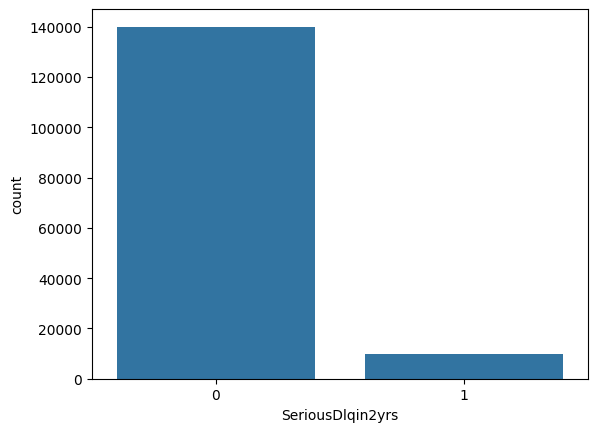

In [5]:
sns.countplot(
    x = "SeriousDlqin2yrs",
    data = df
)
plt.show()

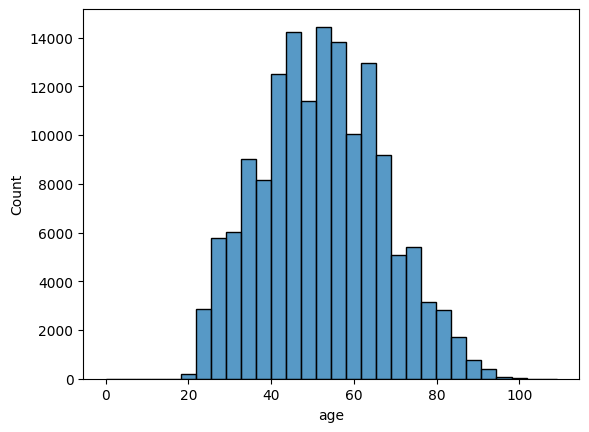

In [6]:
sns.histplot(df["age"], bins = 30)
plt.show()

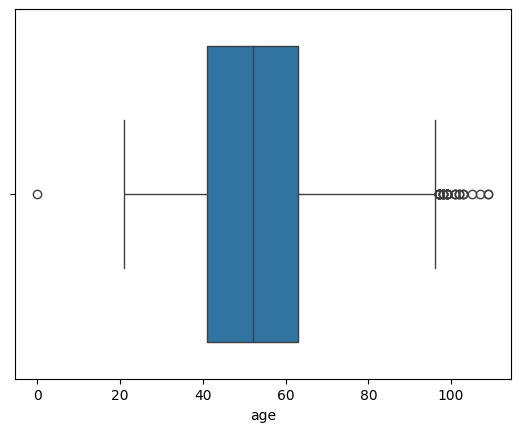

In [7]:
sns.boxplot(x = df["age"])
plt.show()

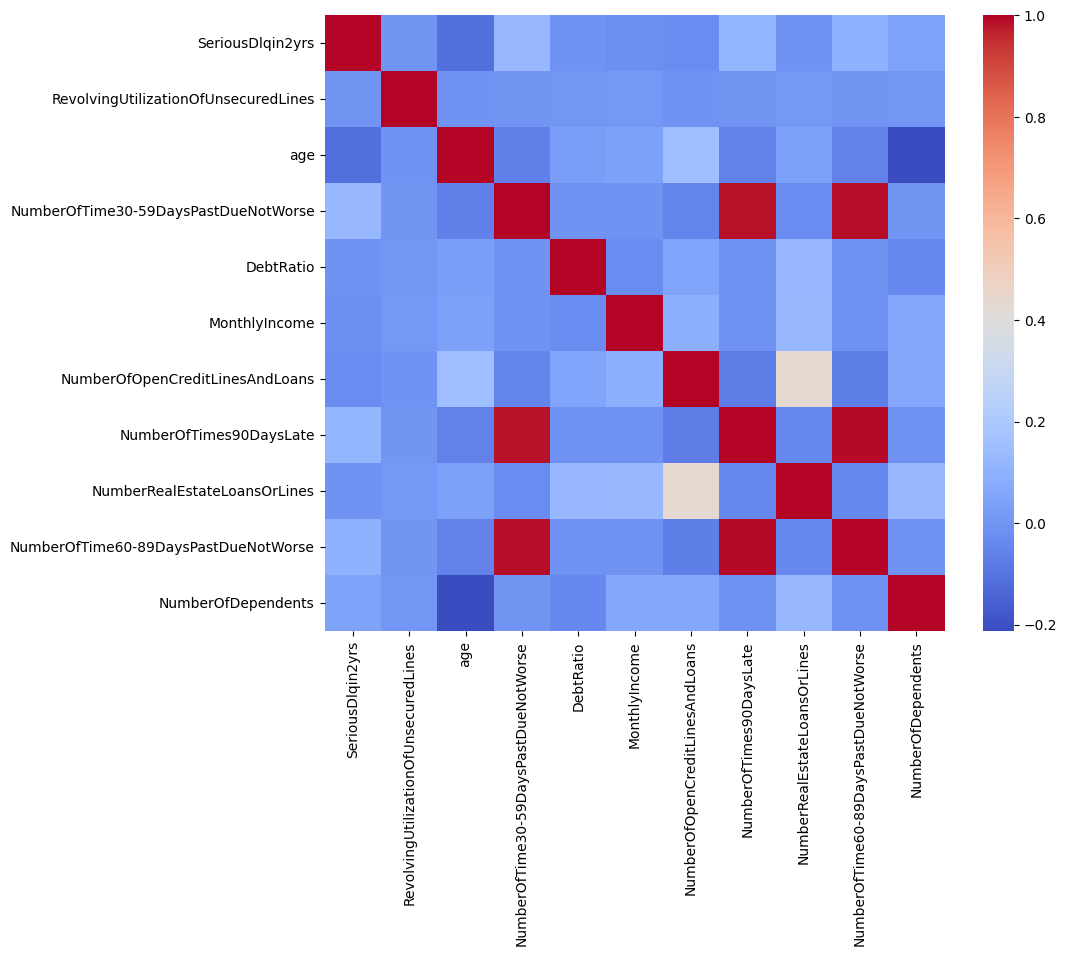

In [8]:
plt.figure(figsize = (10, 8))

sns.heatmap(
    df.corr(),
    cmap = "coolwarm"
)
plt.show()

In [9]:
df.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [10]:
df["MonthlyIncome"] = df["MonthlyIncome"].fillna(df["MonthlyIncome"].median())

In [11]:
df.isnull().sum()

SeriousDlqin2yrs                           0
RevolvingUtilizationOfUnsecuredLines       0
age                                        0
NumberOfTime30-59DaysPastDueNotWorse       0
DebtRatio                                  0
MonthlyIncome                              0
NumberOfOpenCreditLinesAndLoans            0
NumberOfTimes90DaysLate                    0
NumberRealEstateLoansOrLines               0
NumberOfTime60-89DaysPastDueNotWorse       0
NumberOfDependents                      3924
dtype: int64

In [12]:
df["NumberOfDependents"] = df["NumberOfDependents"].fillna(df["NumberOfDependents"].median())
df.isnull().sum()

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

In [13]:
df = df[df["age"] > 18]

In [14]:
df.isnull().sum()

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

In [15]:
df["MonthlyIncome"].describe()

count    1.499990e+05
mean     6.418458e+03
std      1.289044e+04
min      0.000000e+00
25%      3.903000e+03
50%      5.400000e+03
75%      7.400000e+03
max      3.008750e+06
Name: MonthlyIncome, dtype: float64

In [16]:
# Feature Engineering

df["DebtIncomeRatio"] = (
    df["DebtRatio"]*df["MonthlyIncome"]
)

In [17]:
df[["DebtRatio", "MonthlyIncome", "DebtIncomeRatio"]].head()
df.shape

(149999, 12)

In [18]:
df["Totallatepayments"] = (
    df["NumberOfTime30-59DaysPastDueNotWorse"]
    +
    df["NumberOfTime60-89DaysPastDueNotWorse"]
    +
    df["NumberOfTimes90DaysLate"]


)

In [19]:
# Target and Feature

x = df.drop(
    "SeriousDlqin2yrs",
    axis = 1

)

y = df["SeriousDlqin2yrs"]

In [20]:
# Train Test split

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify=y

)

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [22]:
import joblib

joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

In [23]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(
    class_weight="balanced",
    max_iter = 1000
)

lr.fit(x_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [24]:
y_pred_lr = lr.predict(x_test_scaled)
y_prob_lr = lr.predict_proba(x_test_scaled)[:,1]

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
print(classification_report(y_test, y_pred_lr))
print(
    confusion_matrix(
        y_test,
        y_pred_lr
    )
)


              precision    recall  f1-score   support

           0       0.97      0.78      0.86     27995
           1       0.18      0.67      0.28      2005

    accuracy                           0.77     30000
   macro avg       0.57      0.73      0.57     30000
weighted avg       0.92      0.77      0.82     30000

[[21767  6228]
 [  654  1351]]


In [26]:
auc_lr = roc_auc_score(
    y_test,
    y_prob_lr
)



In [27]:
results = {
    "Logistic regression": auc_lr
}

print(results)

{'Logistic regression': 0.8002411278465739}


In [28]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pose_weight = 14,
    n_estimators = 200,
    max_depth = 4,
    learning_rate = 0.05,
    eval_metric = "auc",
    random_state = 42
)

xgb.fit(x_train, y_train)


c:\Users\rosha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:46:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "scale_pose_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [29]:
y_pred_xgb = xgb.predict(x_test)
y_prob_xgb = xgb.predict_proba(x_test)[:,1]

In [30]:
auc_xgb = roc_auc_score(
    y_test,
    y_prob_xgb
)

print("XGBoost AUC:", auc_xgb)



XGBoost AUC: 0.8697134730596263


In [31]:
results["XGBoost"] = auc_xgb
results

{'Logistic regression': 0.8002411278465739, 'XGBoost': 0.8697134730596263}

In [32]:
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.58      0.19      0.29      2005

    accuracy                           0.94     30000
   macro avg       0.76      0.59      0.63     30000
weighted avg       0.92      0.94      0.92     30000

[[27720   275]
 [ 1622   383]]


In [33]:
results

{'Logistic regression': 0.8002411278465739, 'XGBoost': 0.8697134730596263}

In [34]:
from sklearn.metrics import precision_score, recall_score, f1_score
thresholds = [0.2, 0.3, 0.4, 0.5]

result = []

for threshold in thresholds:

    y_pred = (y_prob_xgb >= threshold).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    result.append([
        threshold,
        precision,
        recall,
        f1
    ])

In [35]:
result

[[0.2, 0.40022935779816515, 0.5221945137157107, 0.45314866911923823],
 [0.3, 0.4713526284701713, 0.3980049875311721, 0.43158464034613303],
 [0.4, 0.5321100917431193, 0.2892768079800499, 0.37479806138933763],
 [0.5, 0.5820668693009119, 0.1910224438902743, 0.2876455125797972]]

In [36]:
threshold_df = pd.DataFrame(result, columns = ["Threshold", "Precision", "Recall", "F1 Score"])
threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.2,0.400229,0.522195,0.453149
1,0.3,0.471353,0.398005,0.431585
2,0.4,0.532110,0.289277,0.374798
3,0.5,0.582067,0.191022,0.287646


In [37]:
y_pred_02 = (y_prob_xgb >= 0.2).astype(int)
print(confusion_matrix(y_test, y_pred_02))

[[26426  1569]
 [  958  1047]]


In [38]:
important_df = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": xgb.feature_importances_
})

importance_df = important_df.sort_values(
    by ="Importance",
    ascending=False
)

important_df

,Feature,Importance
0,RevolvingUtilizationOfUnsecuredLines,0.103650
1,age,0.014936
2,NumberOfTime30-59DaysPastDueNotWorse,0.029947
3,DebtRatio,0.012539
4,MonthlyIncome,0.010589
5,NumberOfOpenCreditLinesAndLoans,0.012814
6,NumberOfTimes90DaysLate,0.095450
7,NumberRealEstateLoansOrLines,0.020534
8,NumberOfTime60-89DaysPastDueNotWorse,0.021338
9,NumberOfDependents,0.007431


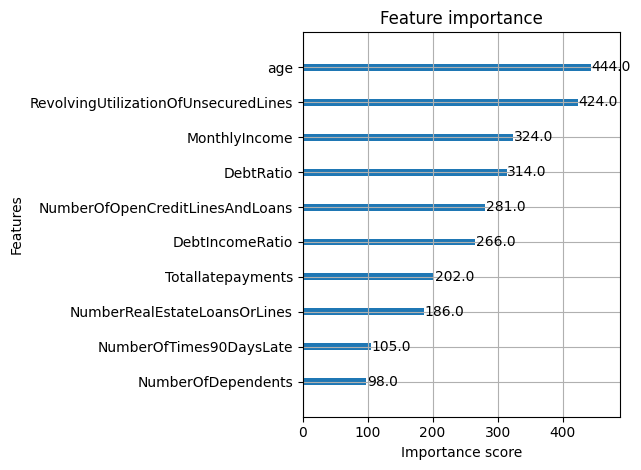

In [47]:
from xgboost import plot_importance
plot_importance(
    xgb,
    max_num_features=10
)

plt.tight_layout()

plt.savefig(
    "feature_importance.png"
)

In [40]:
import shap

explainer = shap.TreeExplainer(xgb)

shape_values = explainer.shap_values(x_test)

c:\Users\rosha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


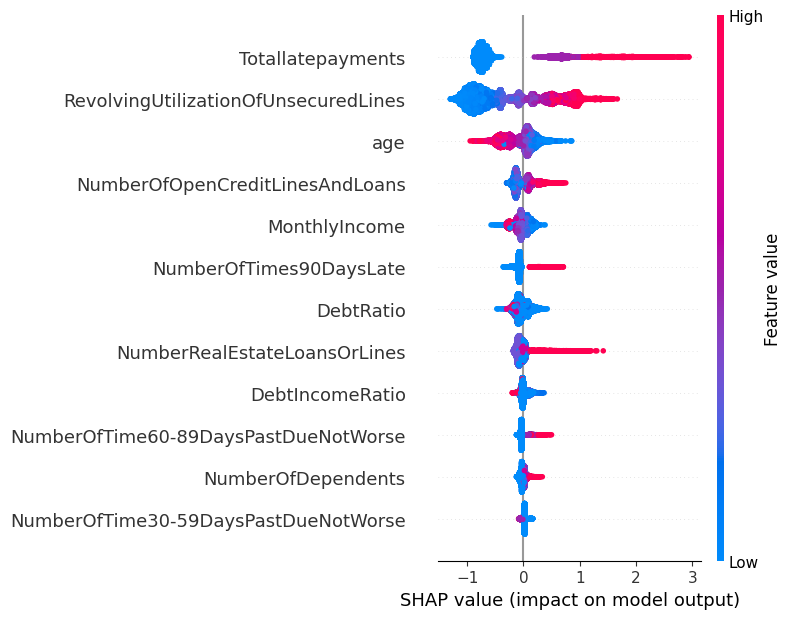

In [48]:
shap.summary_plot(shape_values, x_test, show=False)
plt.tight_layout()

plt.savefig(
    "shape_summary.png",
    bbox_inches="tight"
)

In [42]:
import joblib

joblib.dump(
    xgb,
    "loan_default_xgb.pkl"
)

['loan_default_xgb.pkl']

In [43]:
joblib.dump(
    scaler,
    "scaler.pkl"
)

BestThreshold = 0.2

In [44]:
import os
print(os.listdir())

['app.py', 'GiveMeSomeCredit-testing.csv', 'GiveMeSomeCredit-training.csv', 'loan_default_xgb.pkl', 'model_training.ipynb', 'requirements.txt', 'scaler.pkl']


In [46]:
features_name = x.columns.tolist()

features_name

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents',
 'DebtIncomeRatio',
 'Totallatepayments']